# 039. 네이버 영화평 감성 분류 - sentencepiece 이용

- Google SentencePiece tokenizer 를 이용한 한국어 영화평 감성 분류

In [4]:
# !pip install sentencepiece

In [1]:
import sentencepiece as spm

import numpy as np
import pandas as pd
import re
import time
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, Dense, LSTM

- 이전에 train 해 놓은 tokenizer load

In [14]:
vocab_size = 30000
path = 'nsmc'

sp = spm.SentencePieceProcessor()
sp.Load('{}.model'.format(path))

True

In [15]:
DATA_TRAIN_PATH = tf.keras.utils.get_file("ratings_train.txt", 
            "https://github.com/ironmanciti/NLP_lecture/raw/master/data/naver_movie/ratings_train.txt")
DATA_TEST_PATH = tf.keras.utils.get_file("ratings_test.txt", 
            "https://github.com/ironmanciti/NLP_lecture/raw/master/data/naver_movie/ratings_test.txt")

In [16]:
train_data = pd.read_csv(DATA_TRAIN_PATH, delimiter='\t')
print(train_data.shape)
train_data.head(3)

(150000, 3)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0


In [17]:
test_data = pd.read_csv(DATA_TEST_PATH, delimiter='\t')
print(test_data.shape)
test_data.head(3)

(50000, 3)


,id,document,label
0,6270596,굳 ㅋ,1
1,9274899,GDNTOPCLASSINTHECLUB,0
2,8544678,뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아,0


### 훈련 시간을 감안하여 data size 축소

In [18]:
train_data = train_data.sample(n=50000, random_state=1)
test_data = test_data.sample(n=5000, random_state=1)

print(train_data.shape)
print(test_data.shape)

(50000, 3)
(5000, 3)


**null value 제거**

In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 50000 entries, 58397 to 71565
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        50000 non-null  int64 
 1   document  49997 non-null  object
 2   label     50000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.5+ MB


In [8]:
train_data.dropna(inplace=True)

In [9]:
test_data.dropna(inplace=True)

- tokenizer test

In [19]:
test = "아버지가 방에 들어가신다"
print(sp.encode_as_pieces(test))
print(sp.encode_as_ids(test), '\n') 

['▁아버지가', '▁방', '에', '▁들어가', '신', '다']
[6161, 1569, 16, 3870, 267, 23] 



In [31]:
test = "아버지가방에들어가신다"
pieces = sp.encode_as_pieces(test)
print(pieces)
ids = sp.encode_as_ids(test)
print(ids, '\n') 

['▁아버지가', '방', '에', '들어가', '신', '다']
[6161, 618, 16, 13140, 267, 23] 



In [32]:
print(sp.DecodePieces(pieces))
print(sp.DecodeIds(ids))

아버지가방에들어가신다
아버지가방에들어가신다


## Text Data 전처리

**한글 문자가 아닌 것 모두 제거**

In [33]:
def preprocessing(sentence, remove_stopwords=True): 
    sentence = re.sub('\\\\n', ' ', sentence)              # 개행문자 제거
    sentence = re.sub(r'[^가-힣ㄱ-ㅎㅏ-ㅣ\s]', "", sentence)  #한글외에 모두 제거
    sequences = sp.encode_as_ids(sentence)
    return sequences

In [24]:
clean_train = []
train_labels = []
clean_test = []
test_labels = []

for i, (sent, label) in enumerate(zip(train_data['document'], train_data['label'])):
    if i % 10000 == 0:
        print(f"train processed = {i}")
    sent = preprocessing(sent)
    if len(sent) > 0:
        clean_train.append(sent)
        train_labels.append(label)

for i, (sent, label) in enumerate(zip(test_data['document'], test_data['label'])):
    if i % 1000 == 0:
        print(f"test processed = {i}")
    sent = preprocessing(sent)
    if len(sent) > 0:
        clean_test.append(sent)
        test_labels.append(label)

train processed = 0
train processed = 10000
train processed = 20000
train processed = 30000
train processed = 40000
test processed = 0
test processed = 1000
test processed = 2000
test processed = 3000
test processed = 4000


In [25]:
len(clean_train), len(train_labels), len(clean_test), len(test_labels)

(49571, 49571, 4951, 4951)

In [27]:
print(train_labels[0], '/', clean_train[0])
print()
print(test_labels[0], '/', clean_test[0])

1 / [332, 1774, 18, 13422, 40, 8626, 22878, 4, 19841, 46, 5187, 127, 12720, 114, 2130, 48, 3869, 330, 4996, 22, 7494, 491, 4, 9, 1067, 18, 280, 42, 12, 105, 11881, 237, 2488, 12, 13422, 2263, 12494, 9, 2364, 27, 13442, 4, 17014, 13, 1457]

1 / [19028, 3627, 7587, 200, 6109, 4452, 2691, 461, 1040, 14354]


sample max length : 100
sample mean length: 12


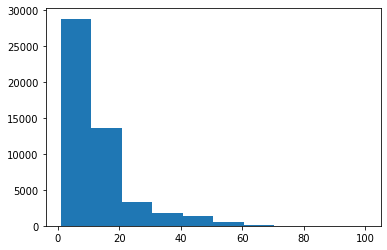

In [28]:
print('sample max length : {}'.format(max(len(s) for s in clean_train)))
print('sample mean length: {:.0f}'.format(np.mean([len(s) for s in clean_train])))

plt.hist([len(s) for s in clean_train]);

In [29]:
MAX_SEQUENCE_LENGTH = 30

In [30]:
train_inputs = pad_sequences(clean_train, 
                            maxlen=MAX_SEQUENCE_LENGTH,
                            padding='post', truncating='post')
train_labels = np.array(train_labels)

test_inputs = pad_sequences(clean_test, 
                            maxlen=MAX_SEQUENCE_LENGTH,
                            padding='post', truncating='post')
test_labels = np.array(test_labels)

len(train_inputs), len(train_labels), len(test_inputs), len(test_labels)

(49571, 49571, 4951, 4951)

In [31]:
print(train_inputs[:2])
print()
print(test_inputs[:2])

[[  332  1774    18 13422    40  8626 22878     4 19841    46  5187   127
  12720   114  2130    48  3869   330  4996    22  7494   491     4     9
   1067    18   280    42    12   105]
 [   37  6567  3776    20   924   585 12340   946     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0]]

[[19028  3627  7587   200  6109  4452  2691   461  1040 14354     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0]
 [  121   226   825   171   887   104  1044   110     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0]]


In [32]:
model = Sequential([
    Embedding(vocab_size +1, 64),
    Bidirectional(LSTM(64)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', 
              optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, None, 64)          1920064   
_________________________________________________________________
bidirectional (Bidirectional (None, 128)               66048     
_________________________________________________________________
dense (Dense)                (None, 32)                4128      
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 33        
Total params: 1,990,273
Trainable params: 1,990,273
Non-trainable params: 0
_________________________________________________________________


In [33]:
num_epochs = 5
history = model.fit(train_inputs, train_labels, epochs=num_epochs,
                           batch_size=128, validation_data=(test_inputs, test_labels),
                           verbose=1)

Epoch 1/5
388/388 [==============================] - 9s 9ms/step - loss: 0.4692 - accuracy: 0.7652 - val_loss: 0.3787 - val_accuracy: 0.8326
Epoch 2/5
388/388 [==============================] - 3s 7ms/step - loss: 0.2688 - accuracy: 0.8911 - val_loss: 0.3872 - val_accuracy: 0.8350
Epoch 3/5
388/388 [==============================] - 3s 7ms/step - loss: 0.1820 - accuracy: 0.9271 - val_loss: 0.5020 - val_accuracy: 0.8295
Epoch 4/5
388/388 [==============================] - 3s 7ms/step - loss: 0.1207 - accuracy: 0.9510 - val_loss: 0.5948 - val_accuracy: 0.8269
Epoch 5/5
388/388 [==============================] - 3s 7ms/step - loss: 0.0807 - accuracy: 0.9676 - val_loss: 0.7555 - val_accuracy: 0.8223


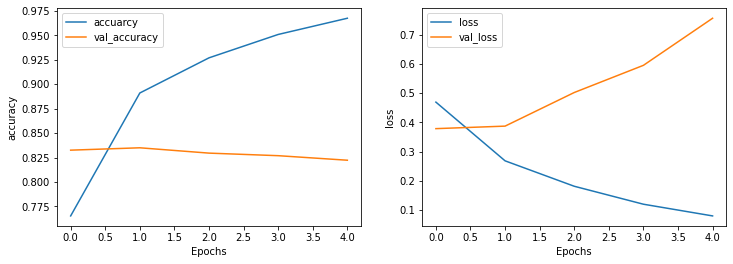

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'])
ax1.plot(history.history['val_accuracy'])
ax1.set_xlabel('Epochs')
ax1.set_ylabel('accuracy')
ax1.legend(['accuarcy', 'val_accuracy'])

ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_xlabel('Epochs')
ax2.set_ylabel('loss')
ax2.legend(['loss', 'val_loss'])
plt.show()

In [42]:
# sample_text = '이 영화는 정말 짜증나서 못 보겠다'
# sample_text = '이렇게 감동적인 영화는 정말 간만이다'
# sample_text = "재미 쩐다"
sample_text = '주인공 연기는 좋았지만 전반적으로 매우 지루한 느낌의 영화'

sample_seq = sp.encode_as_ids(sample_text )
sample_padded = pad_sequences([sample_seq], 
                              maxlen=MAX_SEQUENCE_LENGTH, padding='post')

y_pred = model.predict([sample_padded])
print(y_pred)

['positive' if model.predict([sample_padded]) >= 0.5 else 'negative']

[[0.00339162]]


['negative']